# Implementing simple Chatbot Using LangGraph

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]


In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
openai_base_url = os.getenv("OPENAI_BASE_URL")

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-5.2",
    api_key=openai_api_key,
    base_url=openai_base_url
)
llm

ChatOpenAI(profile={'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002D35C8ADA90>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002D35C8AE660>, root_client=<openai.OpenAI object at 0x000002D35C37A900>, root_async_client=<openai.AsyncOpenAI object at 0x000002D35C8AE3C0>, model_name='gpt-5.2', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://www.yxaiapp.com/v1')

In [4]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
def superbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

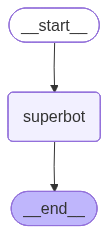

In [6]:
builder = StateGraph(State)

builder.add_node("superbot", superbot)

builder.add_edge(START, "superbot")
builder.add_edge("superbot", END)

graph = builder.compile(checkpointer=memory)

from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='e23167a0-fefc-4bd0-9109-489c0e26f9bc'),
  AIMessage(content='Hi Krish! Nice to meet you. What do you like most about cricket—batting, bowling, fielding, or watching matches?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 17, 'total_tokens': 50, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'resp_07b40ae627ab18480169bb944e951c8196b332c094395c249e', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d04bb-6455-7a00-9af8-d68116933e86-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens'

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

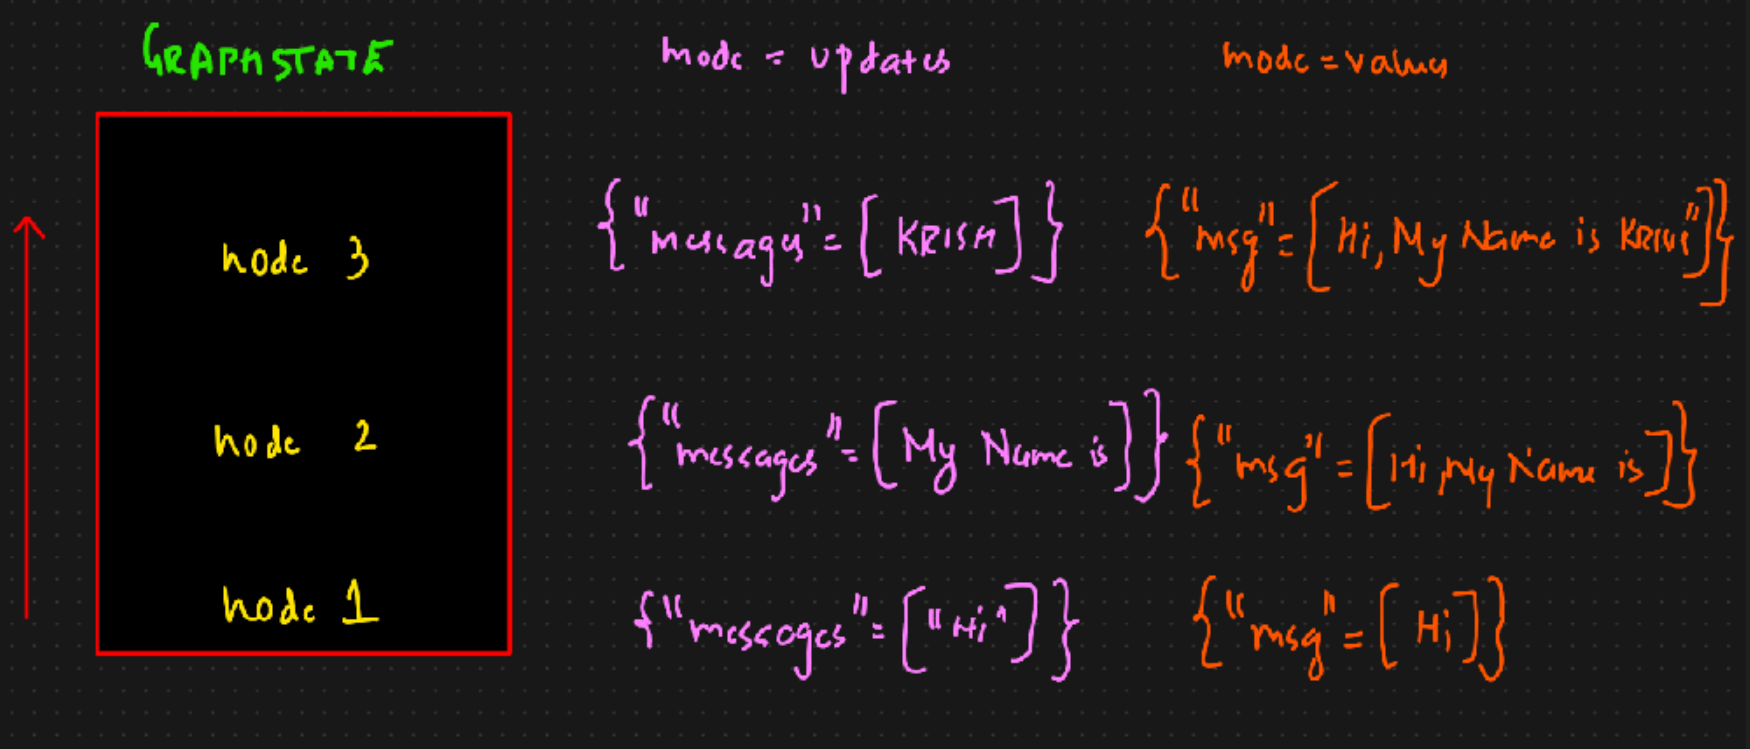

# Streaming The Responses With Stream Method

In [12]:
config = {"configurable": {"thread_id": "2"}}
for chunk in graph.stream({'messages':"Hi,My name is Krish And I like cricket"}, config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hi Krish! That’s cool—cricket has so much to enjoy.\n\nWhat kind of cricket are you into:\n- Playing or watching?\n- Favorite team/player?\n- T20, ODI, or Test?\n\nTell me a bit and I’ll chat with you about it.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 229, 'total_tokens': 313, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 22, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'resp_06e904d7dcce8a960169bb95332c188195aa4cf3700dec5684', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d04be-e19c-7381-9740-09c5d2e65d3e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 229, 'output_tokens': 84, 'total_tokens': 313, 'input_toke

In [ ]:

for chunk in graph.stream({'messages':"Hi,My name is Krish And I like cricket"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='7f64b82d-1c31-4657-95e1-2181548c45ec'), AIMessage(content='Hi Krish! Nice to meet you. What do you like most about cricket—batting, bowling, or watching matches?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 17, 'total_tokens': 47, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'resp_0f1e94671a87d4230169bb94d24a34819597d095aa7bf163e8', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d04bd-66b5-7792-b140-6b9e3fcc9d5c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 30, 'total

In [14]:

for chunk in graph.stream({'messages':"I also like football"}, config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Nice, Krish—cricket and football are a great combo.\n\nDo you mostly **play** football or **watch** it? And which do you like more:\n- **Club football** (like Premier League, La Liga), or\n- **International** (World Cup, national teams)?\n\nWho’s your favorite team or player?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 391, 'total_tokens': 463, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'resp_0205568b1d8007190169bb956c0584819792eb4173f300c16e', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d04bf-be67-7602-84c2-6e1cce007404-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_to

In [15]:

for chunk in graph.stream({'messages':"I like spots"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='7f64b82d-1c31-4657-95e1-2181548c45ec'), AIMessage(content='Hi Krish! Nice to meet you. What do you like most about cricket—batting, bowling, or watching matches?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 17, 'total_tokens': 47, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'resp_0f1e94671a87d4230169bb94d24a34819597d095aa7bf163e8', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d04bd-66b5-7792-b140-6b9e3fcc9d5c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 30, 'total

## Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [16]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph.astream_events({'messages':"Hi,My name is Krish And I like cricket"}, config , version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi,My name is Krish And I like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019d04c7-5f41-78c1-a742-324949e0ca4f', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='ac2a9ca0-09bc-46c0-982e-4c6480011a0f')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019d04c7-5f43-7890-bc73-2a2e412a9cc5', 'metadata': {'thread_id': '3', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:7d4415ac-e765-8529-9a40-da6b431572b8'}, 'parent_ids': ['019d04c7-5f41-78c1-a742-324949e0ca4f']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwa